Appendix A: Code used for Analysis

**DSC 680 Project 1 Milestone 2**

**Calprotectin Levels Correlation with Crohn's Disease and Colitis Flares**

In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [150]:
df = pd.read_csv("hmp2_ibd_metagenomics_atlas_20260219_121629.csv")

In [152]:
df.head()

,External ID,Participant ID,week_num,diagnosis,fecalcal,Bacteroides vulgatus,Bacteroides uniformis,Bacteroides thetaiotaomicron,Faecalibacterium prausnitzii,Roseburia faecis,...,Prevotella histicola,Prevotella pallens,Chlamydia ibidis,Enterococcus mundtii,Anaerostipes sp 992a,Actinobaculum sp oral taxon 183,Lachnoclostridium sp An298,Haemophilus haemolyticus,Enterococcus dispar,Atopobium minutum
0,MSMA26EH,M2069,39,Ulcerative Colitis,493.7,0.0000,0.00000,0.00000,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,MSMA26EH,M2069,39,Ulcerative Colitis,493.7,0.0000,0.00000,0.00000,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,MSMA26EH,M2069,39,Ulcerative Colitis,493.7,0.0000,0.00000,0.00000,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,MSMA26EH,M2069,39,Ulcerative Colitis,493.7,0.0000,0.00000,0.00000,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,HSMA33LB,H4044,16,Ulcerative Colitis,471.3,27.3852,4.15501,0.73033,23.46162,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [154]:
#check for any null values
df.isnull().sum()

External ID                           0
Participant ID                        0
week_num                              0
diagnosis                             0
fecalcal                           2027
                                   ... 
Actinobaculum sp oral taxon 183       0
Lachnoclostridium sp An298            0
Haemophilus haemolyticus              0
Enterococcus dispar                   0
Atopobium minutum                     0
Length: 571, dtype: int64

In [156]:
#show columns with nulls
null_columns = df.columns[df.isnull().any()]
print(null_columns)

Index(['fecalcal'], dtype='object')


In [158]:
#change null fecalcal levels to 0
df['fecalcal'] = df['fecalcal'].fillna(0)

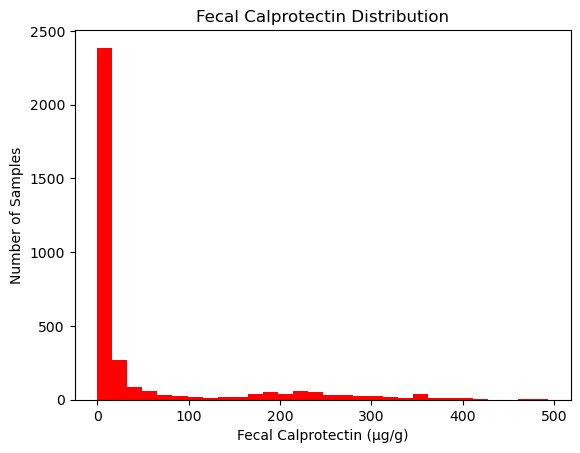

In [160]:
#check to see the distribution of fecalcal level in the dataset
plt.hist(df['fecalcal'], bins=30, color='red')
plt.xlabel('Fecal Calprotectin (µg/g)')
plt.ylabel('Number of Samples')
plt.title('Fecal Calprotectin Distribution')
plt.show()

First I will need to define what a flare is, which is a level of 250 micrograms per gram or higher (an elevated fecal calprotectin level) and to add this label to the dataset as a number of 1 or 0.

In [163]:
#add a column to state whether the person is in a flare or not
df['flare'] = (df['fecalcal'] > 250).astype(int)

df['flare'].value_counts()

flare
0    3165
1     222
Name: count, dtype: int64

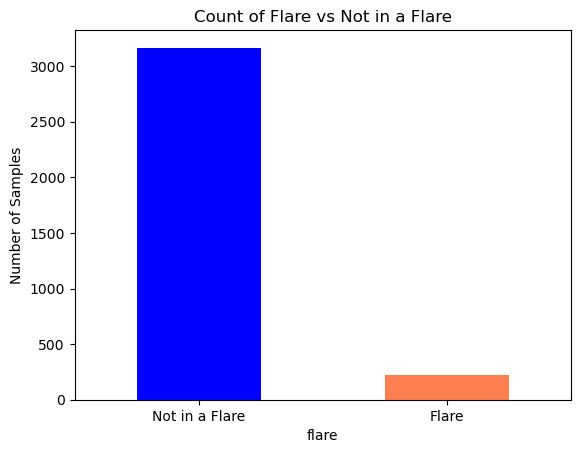

In [165]:
df['flare'].value_counts().plot(kind='bar', color=['Blue', 'Coral'])
plt.xticks([0,1], ['Not in a Flare', 'Flare'], rotation=0)
plt.ylabel('Number of Samples')
plt.title('Count of Flare vs Not in a Flare')
plt.show()

In [167]:
df.head()

,External ID,Participant ID,week_num,diagnosis,fecalcal,Bacteroides vulgatus,Bacteroides uniformis,Bacteroides thetaiotaomicron,Faecalibacterium prausnitzii,Roseburia faecis,...,Prevotella pallens,Chlamydia ibidis,Enterococcus mundtii,Anaerostipes sp 992a,Actinobaculum sp oral taxon 183,Lachnoclostridium sp An298,Haemophilus haemolyticus,Enterococcus dispar,Atopobium minutum,flare
0,MSMA26EH,M2069,39,Ulcerative Colitis,493.7,0.0000,0.00000,0.00000,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,MSMA26EH,M2069,39,Ulcerative Colitis,493.7,0.0000,0.00000,0.00000,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,MSMA26EH,M2069,39,Ulcerative Colitis,493.7,0.0000,0.00000,0.00000,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,MSMA26EH,M2069,39,Ulcerative Colitis,493.7,0.0000,0.00000,0.00000,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,HSMA33LB,H4044,16,Ulcerative Colitis,471.3,27.3852,4.15501,0.73033,23.46162,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


The dataset is a bit imbalanced which will affect how i evaluate my model later on and is important to note.

In [170]:
#drop columns that are not important and the target flare column as well from X
X = df.drop(columns=[
    'External ID',
    'Participant ID',
    'fecalcal',
    'diagnosis',
    'flare'
])

y = df['flare']

Next I will create testing and training splits in order to train the model and measure it's effectiveness.

In [173]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    #adding stratify to see if it will help with the imbalance
    stratify=y
)

In [175]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [176]:
y_pred = rf.predict(X_test)

In [179]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

print(top_features)

Escherichia coli                  0.028733
Roseburia hominis                 0.025857
Roseburia faecis                  0.020781
Akkermansia muciniphila           0.017967
Roseburia inulinivorans           0.017931
Barnesiella intestinihominis      0.016154
Roseburia intestinalis            0.014960
Faecalibacterium prausnitzii      0.014695
Lawsonibacter asaccharolyticus    0.014009
Coprococcus comes                 0.013807
Bacteroides vulgatus              0.013711
Flavonifractor plautii            0.013387
Bacteroides dorei                 0.013212
Streptococcus parasanguinis       0.013060
Haemophilus parainfluenzae        0.012558
dtype: float64


In [181]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       634
           1       0.95      0.91      0.93        44

    accuracy                           0.99       678
   macro avg       0.97      0.95      0.96       678
weighted avg       0.99      0.99      0.99       678



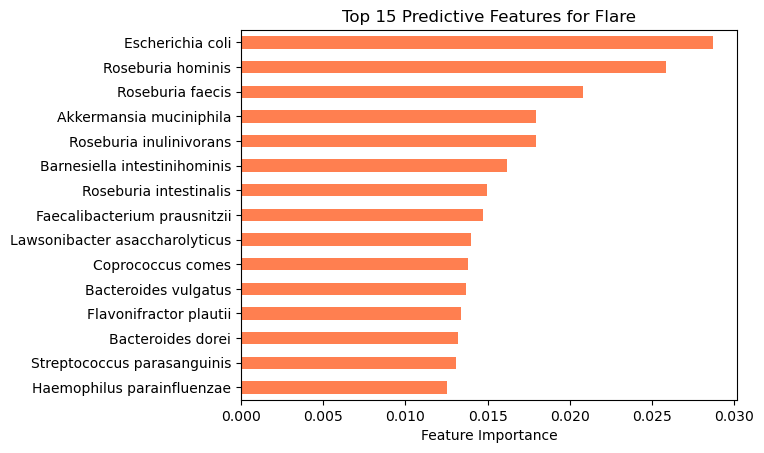

In [183]:
import matplotlib.pyplot as plt

top_features.sort_values().plot(kind='barh', color='coral')
plt.xlabel('Feature Importance')
plt.title('Top 15 Predictive Features for Flare')
plt.show()
#μg/g is the unit